In [16]:
import mordred
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, LSTM
from torch.optim import Adam, AdamW
import os
import matplotlib as mpl
import json

import gc
import os
import pickle
import random
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score as APS
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit
# import duckdb
import pandas as pd
# import mapply
from sklearn.metrics import average_precision_score, precision_recall_curve
from tokenizers import Tokenizer
from transformers import PreTrainedTokenizerFast
from transformers import AutoConfig, AutoTokenizer, AutoModel, DataCollatorWithPadding
import torch
import torch.nn as nn
import torch.nn.functional as F
import importlib
from torch.optim import Adam, AdamW
import matplotlib.pyplot as plt
import gc
import matplotlib as mpl
import json
# from keras.layers import Layer
from rdkit import Chem
# from tensorflow.keras.layers import LeakyReLU

import re
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from biopandas.pdb import PandasPdb
from rdkit.Chem import PandasTools
from sklearn.preprocessing import OneHotEncoder

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
def rdkit_numpy_convert(fp):
    output = []
    for f in fp:
        try:
            arr = np.zeros((1,))
            DataStructs.ConvertToNumpyArray(f, arr)
            arr2=arr
            output.append(arr)
        except:
            output.append(arr2)
            pass
    return np.asarray(output)
smile_data = pd.read_csv('final_fixed_edited.csv',index_col=[0])
fp=[]
for m in tqdm(smile_data.smiles):
    fp.append(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(m), 2,nBits=512))

x = rdkit_numpy_convert(fp) # matrix of descriptors
# calc some descriptors
descr = []
for m in tqdm(smile_data.smiles):
    descr.append([Descriptors.MolLogP(Chem.MolFromSmiles(m)),
                  Descriptors.TPSA(Chem.MolFromSmiles(m)),
                  Descriptors.NHOHCount(Chem.MolFromSmiles(m)),
                  Descriptors.NOCount(Chem.MolFromSmiles(m)),
                  Descriptors.NumHAcceptors(Chem.MolFromSmiles(m)),
                  Descriptors.NumHDonors(Chem.MolFromSmiles(m)),
                  Descriptors.NumRotatableBonds(Chem.MolFromSmiles(m)),
                  Descriptors.NumHeteroatoms(Chem.MolFromSmiles(m)),
                  Descriptors.FractionCSP3(Chem.MolFromSmiles(m)),
                  Descriptors.ExactMolWt(Chem.MolFromSmiles(m)),
                  rdMolDescriptors.CalcNumAromaticRings(Chem.MolFromSmiles(m))])

descr = np.asarray(descr)

# standard_scaler = torch.load('smile_descriptor_scaler_all_data')

# descr_scaled = standard_scaler.transform(descr)

# torch.save(standard_scaler,'smile_descriptor_scaler_all_data')

# x_conc = np.concatenate((x, descr_scaled), axis=1)

x_conc = np.concatenate((x, descr), axis=1)

features_df=pd.DataFrame(x_conc)

all_data = pd.concat([smile_data,features_df],axis=1)

target_names = [x for x in smile_data.columns if 'smiles' not in x and 'core_index' not in x]

morgan_features_to_exclude = []
sums = []
for col in [x for x in all_data.columns if x in features_df.columns and int(x)<2048]:
    sums.append(all_data[col].sum())
    if all_data[col].sum() == 0:
        morgan_features_to_exclude.append(col)
        
all_data = all_data[[x for x in all_data.columns if x not in morgan_features_to_exclude]]

  0%|          | 0/1232 [00:00<?, ?it/s][18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRECATION WARNING: please use MorganGenerator
[18:41:13] DEPRE

In [4]:
indep_test = []
with open('indep_test.txt', 'r') as fp:
    for line in fp.read().splitlines():
        indep_test.append(int(line))

In [5]:
pharma_model_train_val_data = pd.read_csv('molecules_for_train_and_validation.csv', index_col=[0])

In [6]:
pharma_model_train_val_data

,smiles,ALK,AXL,BLK,BMX,BRSK1,BRSK2,BTK,CAMK1D,CHEK1,...,SRC,SRPK1,SYK,TBK1,TEC,TNK2,TXK,TYRO3,ZAP70,sets_split_index
0,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Cc1cc2ncc(-c3ccccc3)nc2cc1C,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,CCCC(=O)Oc1ccc2[nH]c(C(=O)c3cc4ccccc4[nH]3)cc2c1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
6,O=C1NC(=O)c2cc(Nc3ccc(F)cc3)c(Nc3ccc(F)cc3)cc21,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
7,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OC,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,Cn1c(cc(C(F)(F)F)n1)c1cnc(nc1)N1CCc2cc(cc(c12)...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438
1228,C1CC(N(C1)c1cc(cc2CCN(c12)c1ncc(cn1)N)S(Nc1c(c...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1439
1229,C1COCCC1Oc1cc(c(cc1[N+]([O-])=O)[Cl])Nc1ccc2c(...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1440
1230,C(c1ccc(c(c1)[Cl])Nc1ccc2c(c1)NC(N2)=O)#N,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1441


In [7]:
from mordred import Calculator, descriptors

In [8]:
smile_data

,smiles,ALK,AXL,BLK,BMX,BRSK1,BRSK2,BTK,CAMK1D,CHEK1,...,SRC,SRPK1,SYK,TBK1,TEC,TNK2,TXK,TYRO3,ZAP70,core_index
0,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CO[C@H]1C[C@@H]2CC[C@@H](C)[C@@](O)(O2)C(=O)C(...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Cc1cc2ncc(-c3ccccc3)nc2cc1C,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
3,CCCC(=O)Oc1ccc2[nH]c(C(=O)c3cc4ccccc4[nH]3)cc2c1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,O=C1NC(=O)C(c2c[nH]c3ccccc23)=C1c1c[nH]c2ccccc12,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,Cn1c(cc(C(F)(F)F)n1)c1cnc(nc1)N1CCc2cc(cc(c12)...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438
1228,C1CC(N(C1)c1cc(cc2CCN(c12)c1ncc(cn1)N)S(Nc1c(c...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1439
1229,C1COCCC1Oc1cc(c(cc1[N+]([O-])=O)[Cl])Nc1ccc2c(...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1440
1230,C(c1ccc(c(c1)[Cl])Nc1ccc2c(c1)NC(N2)=O)#N,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1441


In [9]:
def All_Mordred_descriptors(data):
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [Chem.MolFromSmiles(smi) for smi in data]
    
    # pandas df
    df = calc.pandas(mols)
    return df

In [10]:
%%time
mordred_descriptors = All_Mordred_descriptors(pharma_model_train_val_data['smiles'])

100%|██████████| 999/999 [00:10<00:00, 97.03it/s] 


CPU times: user 5.86 s, sys: 7.09 s, total: 12.9 s
Wall time: 18.3 s


In [11]:
#remove columns with nan
mordred_descriptors = mordred_descriptors[mordred_descriptors.head(5).describe().columns]

In [12]:
#remove columns with zeroes only
all_0_desc = mordred_descriptors.max(axis=0)[(mordred_descriptors.min(axis=0)==0)&(mordred_descriptors.max(axis=0)==0)].index

In [13]:
all_0_desc

Index(['nB', 'nP', 'NsLi', 'NssBe', 'NssssBe', 'NssBH', 'NsssB', 'NssssB',
       'NddC', 'NsNH3',
       ...
       'n8FaHRing', 'n11FaHRing', 'n4FARing', 'n5FARing', 'n6FARing',
       'n7FARing', 'n4FAHRing', 'n5FAHRing', 'n6FAHRing', 'n7FAHRing'],
      dtype='object', length=156)

In [14]:
mordred_descriptors = mordred_descriptors[[x for x in mordred_descriptors.columns if x not in all_0_desc]]

In [18]:
mordred_descriptors

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,21.339172,16.212841,0,0,35.708519,2.475846,4.814805,35.708519,1.322538,4.236919,...,10.193205,76.227776,377.099811,8.769763,1871,42,144.0,170.0,7.750000,5.888889
1,14.239595,11.165945,0,0,23.924507,2.418829,4.837657,23.924507,1.329139,3.837477,...,9.853825,51.343379,234.115698,7.316116,605,28,96.0,113.0,5.166667,3.916667
2,20.563116,15.859118,0,0,34.043467,2.470284,4.755253,34.043467,1.309364,4.204749,...,10.161573,77.081466,346.131742,7.866631,1837,39,140.0,166.0,7.500000,5.694444
3,21.489002,16.588861,0,0,35.178613,2.489001,4.893004,35.178613,1.302912,4.239911,...,10.233546,76.595095,365.097583,9.127440,1853,42,146.0,172.0,8.361111,5.777778
4,16.958632,13.546673,0,0,28.642859,2.441470,4.882941,28.642859,1.301948,4.021066,...,10.014984,56.167647,315.077454,8.752152,1054,35,114.0,134.0,6.777778,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,35.462154,27.106550,0,0,55.462849,2.553977,5.037212,55.462849,1.260519,4.736575,...,10.928256,99.397435,653.103527,10.047747,7182,78,250.0,303.0,15.902778,9.069444
995,28.056820,22.430064,0,0,44.653987,2.551614,5.033692,44.653987,1.275828,4.506407,...,10.671951,87.891424,520.089594,9.631289,3569,61,196.0,237.0,12.006944,7.347222
996,22.903216,16.928078,0,0,37.740002,2.423373,4.846745,37.740002,1.301379,4.302305,...,10.290619,64.621081,417.109148,8.512432,2362,46,154.0,180.0,8.861111,6.277778
997,15.694249,12.644563,0,0,25.976870,2.410781,4.753477,25.976870,1.298844,3.937073,...,9.872771,67.612561,284.046489,9.794707,865,29,106.0,124.0,6.277778,4.388889


In [21]:
mordred_descriptors_list = mordred_descriptors.columns.tolist()
mordred_descriptors_list

['ABC',
 'ABCGG',
 'nAcid',
 'nBase',
 'SpAbs_A',
 'SpMax_A',
 'SpDiam_A',
 'SpAD_A',
 'SpMAD_A',
 'LogEE_A',
 'VE1_A',
 'VE2_A',
 'VE3_A',
 'VR1_A',
 'VR2_A',
 'VR3_A',
 'nAromAtom',
 'nAromBond',
 'nAtom',
 'nHeavyAtom',
 'nSpiro',
 'nBridgehead',
 'nHetero',
 'nH',
 'nC',
 'nN',
 'nO',
 'nS',
 'nF',
 'nCl',
 'nBr',
 'nI',
 'nX',
 'ATS0dv',
 'ATS1dv',
 'ATS2dv',
 'ATS3dv',
 'ATS4dv',
 'ATS5dv',
 'ATS6dv',
 'ATS7dv',
 'ATS8dv',
 'ATS0d',
 'ATS1d',
 'ATS2d',
 'ATS3d',
 'ATS4d',
 'ATS5d',
 'ATS6d',
 'ATS7d',
 'ATS8d',
 'ATS0s',
 'ATS1s',
 'ATS2s',
 'ATS3s',
 'ATS4s',
 'ATS5s',
 'ATS6s',
 'ATS7s',
 'ATS8s',
 'ATS0Z',
 'ATS1Z',
 'ATS2Z',
 'ATS3Z',
 'ATS4Z',
 'ATS5Z',
 'ATS6Z',
 'ATS7Z',
 'ATS8Z',
 'ATS0m',
 'ATS1m',
 'ATS2m',
 'ATS3m',
 'ATS4m',
 'ATS5m',
 'ATS6m',
 'ATS7m',
 'ATS8m',
 'ATS0v',
 'ATS1v',
 'ATS2v',
 'ATS3v',
 'ATS4v',
 'ATS5v',
 'ATS6v',
 'ATS7v',
 'ATS8v',
 'ATS0se',
 'ATS1se',
 'ATS2se',
 'ATS3se',
 'ATS4se',
 'ATS5se',
 'ATS6se',
 'ATS7se',
 'ATS8se',
 'ATS0pe',
 'ATS1p

In [22]:
with open('mordred_columns2.txt', 'w') as f:
    for col in mordred_descriptors_list:
        f.write(col + '\n')

In [23]:
scaler_mordred = StandardScaler()

In [24]:
%%time
transformed_mordred = scaler_mordred.fit_transform( mordred_descriptors.values )

CPU times: user 18 ms, sys: 1.28 ms, total: 19.3 ms
Wall time: 16.8 ms


In [32]:
# mordred_descriptors.to_csv('collected_mordred_all_data_2.csv')

In [17]:
var_sum = []

n_comp = []

for i in tqdm(np.arange(20,400+1,10)):
    n_comp.append(i)
    pca = PCA(n_components=i)
    pca.fit(transformed_mordred)
    var_sum.append(pca.explained_variance_ratio_.sum())

100%|██████████████████████████████████████████████████████████████████████████████████| 39/39 [05:45<00:00,  8.86s/it]


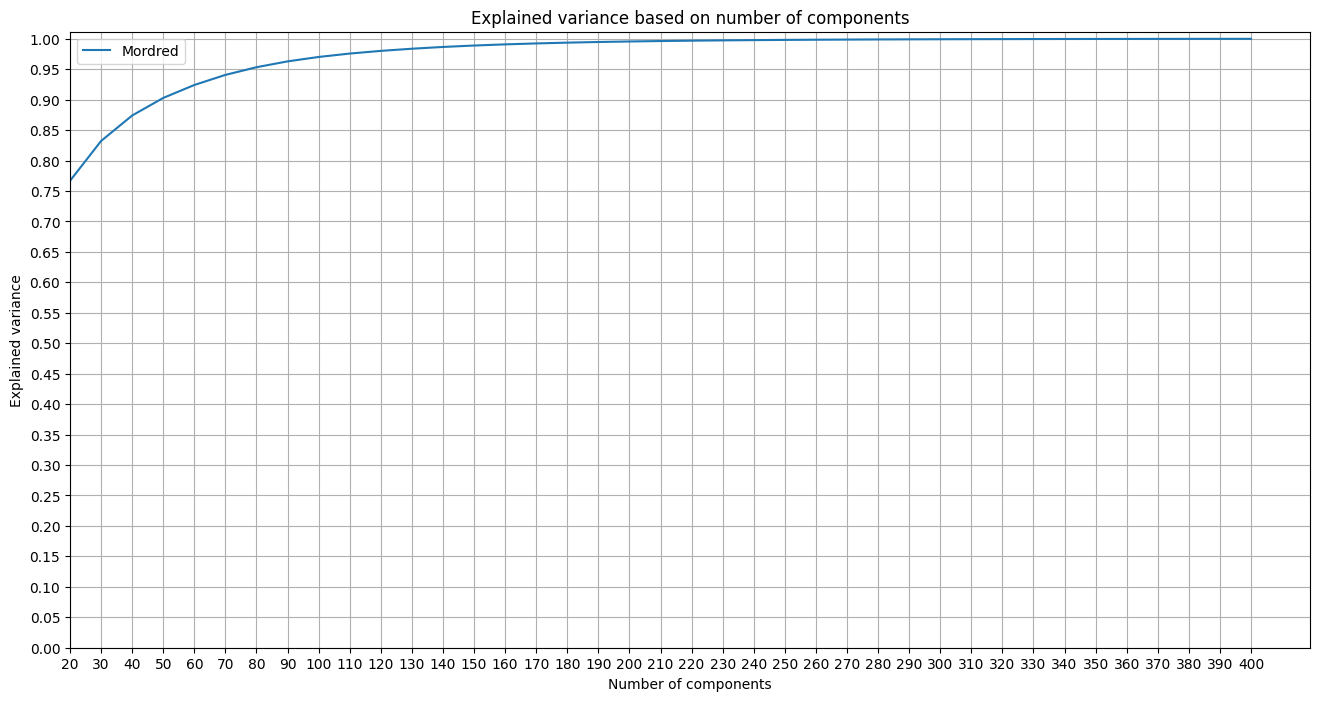

In [18]:
plt.figure(figsize=(16,8))
plt.plot(n_comp,var_sum,label="Mordred")
plt.xlim(401)

plt.xticks(np.arange(20,401,10))
plt.yticks(np.arange(0,1.05,0.05))
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title('Explained variance based on number of components')
plt.grid()
plt.legend()
plt.show()

In [25]:
pca = PCA(n_components=190)
downsized_data = pca.fit_transform(transformed_mordred)

In [26]:
torch.save(pca, 'mordred_neural_pca_4')

In [27]:
torch.save(scaler_mordred, 'mordred_scaler_4')

In [48]:
# scaler_mordred = torch.load('mordred_scaler_4')

In [28]:
all_data_indep_data = all_data[all_data.core_index.isin(indep_test)]

In [76]:
all_data_indep_data

,smiles,ALK,AXL,BLK,BMX,BRSK1,BRSK2,BTK,CAMK1D,CHEK1,...,513,514,515,516,517,518,519,520,521,522
4,O=C1NC(=O)C(c2c[nH]c3ccccc23)=C1c1c[nH]c2ccccc12,0,0,0,0,1,0,0,0,0,...,77.75,3.0,5.0,2.0,3.0,2.0,5.0,0.000000,327.100777,4.0
5,CN(C)CCCn1cc(C2=C(c3c[nH]c4ccccc34)C(=O)NC2=O)...,0,0,0,0,1,0,0,0,0,...,70.13,2.0,6.0,4.0,2.0,6.0,6.0,0.200000,412.189926,4.0
19,CN([C@@H](Cc1ccc(OS(=O)(=O)c2cccc3cnccc23)cc1)...,0,0,0,0,0,0,0,0,0,...,130.08,0.0,11.0,9.0,0.0,10.0,13.0,0.184211,721.202876,6.0
22,COc1cccc(-c2cc(=O)c3ccccc3o2)c1N,0,0,0,0,0,0,0,0,0,...,65.46,2.0,4.0,4.0,1.0,2.0,4.0,0.062500,267.089543,3.0
23,O=S(=O)(c1cccc2cnccc12)N1CCCNCC1,0,0,0,0,0,0,0,0,0,...,62.30,1.0,5.0,4.0,1.0,2.0,6.0,0.357143,291.104148,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,[H][C@]12CN(C[C@]2([H])[C@H]1CNC(c1ccc2c(c1)nn...,0,0,0,0,0,0,0,0,0,...,125.99,2.0,10.0,7.0,2.0,5.0,10.0,0.400000,407.170588,3.0
1203,CCS(c1cc2cc(C[C@@](CC(C)(C)c3ccc(cc3C(N)=O)F)(...,0,0,0,1,0,0,0,0,0,...,126.14,4.0,7.0,5.0,3.0,8.0,12.0,0.391304,515.150190,3.0
1214,CC(C1=C(c2cc(c3ccc(cc3)[Cl])c(c3ccc(cc3[Cl])[C...,0,0,0,0,0,0,0,0,0,...,81.06,1.0,6.0,5.0,1.0,4.0,9.0,0.120000,513.041374,4.0
1222,C[C@H](c1ccc(cc1)F)N(Cc1cccc(c1)C(O)=O)C(c1cc2...,0,0,0,0,0,0,0,0,0,...,70.50,1.0,5.0,3.0,1.0,6.0,6.0,0.115385,428.153621,4.0


In [30]:
all_data_indep_data_mordred = All_Mordred_descriptors(all_data_indep_data['smiles'])

100%|██████████| 177/177 [00:04<00:00, 41.21it/s]


In [32]:
all_data_indep_data_mordred = all_data_indep_data_mordred[mordred_descriptors_list]

In [40]:
all_data_indep_data_mordred

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,20.360915,17.138546,0,0,33.574401,2.559020,4.941106,33.574401,1.342976,4.198622,...,10.366876,77.851381,327.100777,8.607915,1342,43,144.0,179.0,6.361111,5.333333
1,24.781895,20.008418,0,1,40.635134,2.573442,4.955751,40.635134,1.310811,4.390892,...,10.496842,84.745586,412.189926,7.494362,2552,52,172.0,210.0,9.083333,6.694444
2,40.651191,28.259012,0,0,67.558538,2.498167,4.996335,67.558538,1.324677,4.874008,...,11.017891,89.852542,721.202876,8.386080,10912,92,280.0,336.0,14.930556,10.930556
3,15.572928,12.667896,0,0,26.124433,2.446373,4.892746,26.124433,1.306222,3.935971,...,10.025041,53.967671,267.089543,8.093623,775,34,106.0,127.0,6.277778,4.472222
4,15.670087,12.976776,0,1,26.229563,2.476167,4.947929,26.229563,1.311478,3.935851,...,10.022825,61.632947,291.104148,7.867680,746,36,106.0,126.0,5.756944,4.388889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,24.127159,17.741112,0,0,39.950548,2.583886,4.893026,39.950548,1.331685,4.378170,...,10.441413,87.483481,407.170588,7.983737,3114,41,166.0,199.0,8.222222,6.416667
173,27.423195,22.971702,0,0,41.301592,2.513332,5.006565,41.301592,1.180045,4.481511,...,10.720289,86.067998,515.150190,8.585837,3731,62,192.0,228.0,15.888889,7.229167
174,26.702618,21.293734,0,0,42.466752,2.557120,5.114240,42.466752,1.249022,4.459091,...,10.647209,70.826066,513.041374,9.866180,3067,63,184.0,222.0,13.166667,7.305556
175,25.053046,19.226546,1,0,41.795962,2.423964,4.847928,41.795962,1.306124,4.393716,...,10.361893,68.035451,428.153621,8.078370,2905,52,168.0,197.0,10.222222,7.000000


In [45]:
all_data_indep_data_mordred['core_index'] = all_data_indep_data.reset_index().core_index

In [46]:
all_data_indep_data_mordred

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2,core_index
0,20.360915,17.138546,0,0,33.574401,2.559020,4.941106,33.574401,1.342976,4.198622,...,77.851381,327.100777,8.607915,1342,43,144.0,179.0,6.361111,5.333333,4
1,24.781895,20.008418,0,1,40.635134,2.573442,4.955751,40.635134,1.310811,4.390892,...,84.745586,412.189926,7.494362,2552,52,172.0,210.0,9.083333,6.694444,5
2,40.651191,28.259012,0,0,67.558538,2.498167,4.996335,67.558538,1.324677,4.874008,...,89.852542,721.202876,8.386080,10912,92,280.0,336.0,14.930556,10.930556,19
3,15.572928,12.667896,0,0,26.124433,2.446373,4.892746,26.124433,1.306222,3.935971,...,53.967671,267.089543,8.093623,775,34,106.0,127.0,6.277778,4.472222,22
4,15.670087,12.976776,0,1,26.229563,2.476167,4.947929,26.229563,1.311478,3.935851,...,61.632947,291.104148,7.867680,746,36,106.0,126.0,5.756944,4.388889,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,24.127159,17.741112,0,0,39.950548,2.583886,4.893026,39.950548,1.331685,4.378170,...,87.483481,407.170588,7.983737,3114,41,166.0,199.0,8.222222,6.416667,1413
173,27.423195,22.971702,0,0,41.301592,2.513332,5.006565,41.301592,1.180045,4.481511,...,86.067998,515.150190,8.585837,3731,62,192.0,228.0,15.888889,7.229167,1414
174,26.702618,21.293734,0,0,42.466752,2.557120,5.114240,42.466752,1.249022,4.459091,...,70.826066,513.041374,9.866180,3067,63,184.0,222.0,13.166667,7.305556,1425
175,25.053046,19.226546,1,0,41.795962,2.423964,4.847928,41.795962,1.306124,4.393716,...,68.035451,428.153621,8.078370,2905,52,168.0,197.0,10.222222,7.000000,1433


In [47]:
all_data_indep_data_mordred.to_csv('indep_mordred.csv',index=False)

In [59]:
# all_data_training = all_data[~all_data.core_index.isin(indep_test)]
# all_data_indep_data = all_data[all_data.core_index.isin(indep_test)]
pharma_model_train_val_data.reset_index(inplace=True,drop=True)

In [60]:
pharma_model_train_val_data

,smiles,ALK,AXL,BLK,BMX,BRSK1,BRSK2,BTK,CAMK1D,CHEK1,...,SRC,SRPK1,SYK,TBK1,TEC,TNK2,TXK,TYRO3,ZAP70,sets_split_index
0,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Cc1cc2ncc(-c3ccccc3)nc2cc1C,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,CCCC(=O)Oc1ccc2[nH]c(C(=O)c3cc4ccccc4[nH]3)cc2c1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
3,O=C1NC(=O)c2cc(Nc3ccc(F)cc3)c(Nc3ccc(F)cc3)cc21,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,COc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OC,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,Cn1c(cc(C(F)(F)F)n1)c1cnc(nc1)N1CCc2cc(cc(c12)...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438
995,C1CC(N(C1)c1cc(cc2CCN(c12)c1ncc(cn1)N)S(Nc1c(c...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1439
996,C1COCCC1Oc1cc(c(cc1[N+]([O-])=O)[Cl])Nc1ccc2c(...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1440
997,C(c1ccc(c(c1)[Cl])Nc1ccc2c(c1)NC(N2)=O)#N,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1441


In [81]:
# all_data_indep_data.reset_index(drop=True,inplace=True)
all_data_indep_data[TARGETS+['core_index']].to_csv('mordred_indep_labels.csv',index=False)

In [61]:
class MORDNN(nn.Module):
    def __init__(self, inp_dim=190, linear_neurons=1024, dropout=0.5):
        super(MORDNN, self).__init__()
        self.linear_neurons = linear_neurons
        self.inp_dim = inp_dim
        
        self.lstm = nn.LSTM(inp_dim, linear_neurons, batch_first=True)
        
        self.dropout = nn.Dropout(p=0.5)

        self.out_mlp = nn.Sequential(Linear(in_features=linear_neurons, out_features=linear_neurons // 2),
                             nn.BatchNorm1d(linear_neurons // 2),
                             nn.ReLU(),
                             nn.Dropout(dropout),
                             Linear(in_features=linear_neurons // 2, out_features=linear_neurons //4),
                             nn.BatchNorm1d(linear_neurons // 4),
                             nn.ReLU(),
                             nn.Dropout(dropout),
                             Linear(in_features=linear_neurons // 4, out_features=linear_neurons // 4),
                             nn.BatchNorm1d(linear_neurons // 4),
                             nn.ReLU(),
                             nn.Dropout(dropout),
                             Linear(in_features=linear_neurons // 4, out_features=linear_neurons // 8),
                             nn.BatchNorm1d(linear_neurons // 8),
                             nn.ReLU(),
                             nn.Dropout(dropout),
                             )

        self.layer_out = Linear(in_features=linear_neurons // 8, out_features=75)


    
    def forward(self, x):
        batch_size = x.size(0)
        out = self.lstm(x.reshape(len(x), -1, self.inp_dim))
        batch_size, max_len, input_size = out[0].shape
        out = self.dropout(out[0])
        out = self.out_mlp(out.reshape(-1, input_size))
        out = self.layer_out(out)
        return out
    
def get_loader(X, y, shuffle=False, batch_size=4096):
    train = torch.utils.data.TensorDataset(torch.from_numpy(X).float(), 
                                       torch.from_numpy(y).long())
    train_loader = torch.utils.data.DataLoader(train, 
                                               batch_size=batch_size,shuffle=shuffle)
    return train_loader

def train_epoch(model, optimizer, train_loader, criterion, device):

    model.train()
    for obj,target in train_loader:
        obj = obj.to(device)
        target = target.to(device)
        
        #forward pass
        outputs = model(obj)
        loss = criterion(outputs,target.float())

        #backward pass
        optimizer.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        

def evaluate_loss(loader, model, criterion, device):

    model.eval()
    with torch.no_grad():

        for obj, target in loader:
            obj = obj.to(device)
            target = target.to(device)
            
            outputs = model(obj)
            loss = criterion(outputs,target.float())
            
    return(loss)

    
def train_m_v3(model, opt, train_loader, val_loader, criterion, n_epochs, device, name,
               early_stop=5, scheduler=None, verbose=True):
    train_log = []
    val_log = []
    val_min = np.inf
    train_min = np.inf
    epoch_min = 0
    fixed_epoch_val = 0
    fixed_epoch_train = 0
    val_allowed_maximum = np.inf
    early_counter = 0

    for epoch in tqdm(range(n_epochs)):
        train_epoch(model, opt, train_loader, criterion, device)
        train_loss = evaluate_loss(train_loader, model, criterion, device)

        val_loss = evaluate_loss(val_loader, model,
                                 criterion, device)
        
        if scheduler is not None:
            scheduler.step(val_loss)
            
        train_log.append(train_loss.cpu().numpy().item())
        val_log.append(val_loss.cpu().numpy().item())
        if val_loss < val_min:
            val_min = val_loss.cpu().numpy().item()
            epoch_val_absolute_min = epoch
            val_allowed_maximum = val_loss * 1.001 #removed allowance for validation fluctuation

        if train_loss < train_min:
            train_min = train_loss

        if val_loss <= val_allowed_maximum:
            epoch_min = epoch
            fixed_epoch_val = val_loss.cpu().numpy().item()
            fixed_epoch_train = train_min.cpu().numpy().item()
            torch.save(model.state_dict(), name)
            torch.save({
                'epoch': epoch_min,
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss_history': train_log,
                'val_loss_history': val_log,
            }, name + 'training_optimizer_logs_')
            early_counter = 0
        # if epoch==5:
        #     torch.save(model.state_dict(), name+'_5')
        # if epoch==10:
        #     torch.save(model.state_dict(), name+'_10')
        # if epoch==15:
        #     torch.save(model.state_dict(), name+'_15')

        if val_loss > val_allowed_maximum:
            early_counter += 1

        if verbose:
            if epoch % 10 == 0:
                print(('Epoch [%d/%d], Loss (train/test): %.4f/%.4f'
                       % (epoch + 1, n_epochs, \
                          train_loss, val_loss)))

        res_dict = {'min_loss_epoch': epoch_min,
                    'train_min': train_min.cpu().numpy().item(),
                    'train_loss_history': train_log,
                    'val_loss_history': val_log,
                    'val_min': val_min,
                    'final_val': fixed_epoch_val,
                    'final_train': fixed_epoch_train}

        if early_counter == early_stop:
            print(
                f'Early stopping after epoch {epoch}, model saved at epoch {epoch_min}, validation loss {fixed_epoch_val}.')
            return res_dict

    return res_dict

In [62]:
validation_idx = []
atms_test = pd.read_csv('74_kin_phar_validation_'+str(13)+'.csv')    
validation_idx.append(atms_test.core_index.unique())

for seeds in ['146','26','265','553']:
    with open(f'validation_seed_{seeds}.txt', 'r') as fp:
        indeces = []
        for line in fp.read().splitlines():
            indeces.append(int(line))
    validation_idx.append(indeces)

In [63]:
len(validation_idx)

5

In [64]:
def get_indep_loader(X, shuffle=False, batch_size=4096):
    train = torch.utils.data.TensorDataset(torch.from_numpy(X).float())
    train_loader = torch.utils.data.DataLoader(train, 
                                               batch_size=batch_size,shuffle=shuffle)
    return train_loader


In [86]:
device = torch.device('cuda')

MODEL_VERSION = 'V1_5'
DATA_SET_SIZE = '75_kin'
EARLY_STOP = 20
BATCH_SIZE = 128
TARGETS = [x for x in smile_data.columns if 'smiles' not in x and 'core_index' not in x]
val_seeds = ['13','146','26','265','553']
for fold in range(5):

    seed = val_seeds[fold]
    
    val_idx = validation_idx[fold]

    data_val = downsized_data[pharma_model_train_val_data[pharma_model_train_val_data.sets_split_index.isin(val_idx)].index]

    data_training = downsized_data[pharma_model_train_val_data[~pharma_model_train_val_data.sets_split_index.isin(val_idx)].index]

    y_train = pharma_model_train_val_data[~pharma_model_train_val_data.sets_split_index.isin(val_idx)][TARGETS].to_numpy()

    y_val = pharma_model_train_val_data[pharma_model_train_val_data.sets_split_index.isin(val_idx)][TARGETS].to_numpy()

    train_loader = get_loader(data_training, y_train,batch_size=BATCH_SIZE, shuffle=True) 
    
    val_loader = get_loader(data_val, y_val,batch_size=BATCH_SIZE, shuffle=False)

    print(val_seeds[fold], len(all_data_indep_data),len(data_val),len(data_training))
    
    epochs = 200
    
    # class_weight = 1
    
    neural = MORDNN(linear_neurons=2024,dropout=0.5)
    neural = neural.to(device)
    optimizer = Adam(neural.parameters(), lr=0.001)
    # optimizer =  AdamW(neural.parameters(), lr=0.00001, weight_decay=0.0001)
    loss = nn.BCEWithLogitsLoss() 
    
    curr_name = f"MORDRED_MLP_{DATA_SET_SIZE}_{seed}_{MODEL_VERSION}"
    
    neural_folder = 'mordred_neurals_3/'
    
    os.makedirs(neural_folder,exist_ok=True)
    
    
    
    res_dict = train_m_v3(neural, optimizer, train_loader, val_loader, loss, epochs, 
                      device, neural_folder+curr_name, early_stop=EARLY_STOP, verbose=True)
    
    del train_loader   
    
    with torch.cuda.device(device):
        torch.cuda.empty_cache()
    
    mpl.rcParams['figure.dpi'] = 150
    print(res_dict['min_loss_epoch'], res_dict['final_val'], res_dict['final_train'], res_dict['val_min'])
    
    with open(os.path.join(neural_folder, curr_name+'_results.txt'), "w") as f:
        f.write(json.dumps(res_dict))
    
    y1 = []
    y2 = []
    for lg in res_dict['train_loss_history']:
        y1.append(lg)
    for lg in res_dict['val_loss_history']:
        y2.append(lg)
    x = range(1,len(y1)+1)
    plt.plot(x,y1, label = 'train loss')
    plt.plot(x,y2, label = 'val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(neural_folder+curr_name+'_loss_func.png')
    plt.clf()
    plt.close()


13 177 150 849


  0%|          | 1/200 [00:00<01:19,  2.51it/s]

Epoch [1/200], Loss (train/test): 0.6416/0.6407


  5%|▌         | 10/200 [00:03<00:51,  3.66it/s]

Epoch [11/200], Loss (train/test): 0.1902/0.1899


...

Epoch [41/200], Loss (train/test): 0.1062/0.1330


 27%|██▋       | 54/200 [00:09<00:08, 17.05it/s]

Epoch [51/200], Loss (train/test): 0.1113/0.1331


 28%|██▊       | 55/200 [00:09<00:25,  5.59it/s]


Early stopping after epoch 55, model saved at epoch 35, validation loss 0.12524975836277008.
35 0.12524975836277008 0.11441999673843384 0.12524975836277008


In [87]:
##by label optimization using
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from scipy.optimize import fmin_l_bfgs_b, basinhopping
from sklearn.metrics import fbeta_score
from scipy.optimize import minimize
def best_fb_score(true_labels, predictions,beta):

    def f_neg(threshold):
        ## Scipy tries to minimize the function so we must get its inverse
        return - fbeta_score(true_labels, predictions > threshold, beta=beta, average='binary')

     # Initialization of best threshold search
    thr_0 = [0.20] 
    constraints = [(0.,1.)] 
    def bounds(**kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x < 1))
        tmin = bool(np.all(x > 0)) 
        return tmax and tmin
    
    # Search using L-BFGS-B, the epsilon step must be big otherwise there is no gradient
    minimizer_kwargs = {"method": "L-BFGS-B",
                        "bounds":constraints,
                        "options":{
                            "eps": 0.05
                            }
                       }
    
    # We combine L-BFGS-B with Basinhopping for stochastic search with random steps

    
    opt_output = basinhopping(f_neg, thr_0,
                                stepsize = 0.05,
                                minimizer_kwargs=minimizer_kwargs,
                                niter=10,
                                accept_test=bounds)
    score = - opt_output.fun
    return score, opt_output.x

In [88]:
device = torch.device('cuda')

MODEL_VERSION = 'V1_5'
DATA_SET_SIZE = '75_kin'
EARLY_STOP = 20
BATCH_SIZE = 128
TARGETS = [x for x in smile_data.columns if 'smiles' not in x and 'core_index' not in x]
val_seeds = ['13','146','26','265','553']

indep_data = pd.read_csv('indep_mordred.csv')
transform_indep = scaler_mordred.transform(indep_data[mordred_descriptors_list].values )
data_indep = pca.transform(transform_indep)

indep_labels = pd.read_csv('mordred_indep_labels.csv')

cl_fold = 'mordred_classification_results_4/'
os.makedirs(cl_fold,exist_ok=True)

for fold in range(5):

    seed = val_seeds[fold]
    
    val_idx = validation_idx[fold]

    data_training = downsized_data[pharma_model_train_val_data[~pharma_model_train_val_data.sets_split_index.isin(val_idx)].index]

    y_train = pharma_model_train_val_data[~pharma_model_train_val_data.sets_split_index.isin(val_idx)][TARGETS].to_numpy()

    y_indep = indep_labels[TARGETS].to_numpy()

    train_loader = get_loader(data_training, y_train,batch_size=BATCH_SIZE, shuffle=True) 
    
    indep_loader = get_loader(data_indep, y_indep,batch_size=BATCH_SIZE, shuffle=False)

    print(val_seeds[fold], len(all_data_indep_data),len(val_idx),len(data_training))
    
    epochs = 200
    
    # class_weight = 1
    
    neural = MORDNN(linear_neurons=2024,dropout=0.5)
    neural = neural.to(device)
    optimizer = Adam(neural.parameters(), lr=0.001)
    # optimizer =  AdamW(neural.parameters(), lr=0.00001, weight_decay=0.0001)
    loss = nn.BCEWithLogitsLoss() 
    
    curr_name = f"MORDRED_MLP_{DATA_SET_SIZE}_{seed}_{MODEL_VERSION}"
    
    neural_folder = 'mordred_neurals_3/'

    neural.load_state_dict(torch.load(neural_folder+curr_name,map_location=device))
    
    neural = neural.to(device)

    neural.eval()

    y_train = []
    y_train_preds = []

    with torch.no_grad():

        predictions = []
        
        m = nn.Sigmoid()
        
        for data,y in train_loader:
            out = neural(data.to(device))
            pred = m(out.to(torch.device("cpu"))).detach().numpy()
            y_train_preds.extend(pred)
            predictions.extend((pred>0.25).astype(int))
            y_train.extend(y.to(torch.device("cpu")).detach().numpy())

    print(classification_report(y_train, predictions, target_names=target_names),
      file=open(cl_fold+'cls_reports_025_thr_'+curr_name+'.txt', 'w'))
            
    scores = []
    opt_outputs = []

    
    for i in tqdm(range(len(target_names))):            

        score, opt_output = best_fb_score(np.array(y_train)[:,i],np.array(y_train_preds)[:,i],1)
        scores.append(score)
        opt_outputs.append(opt_output[0])
        
    print(classification_report(y_train, np.array(y_train_preds)>opt_outputs, target_names=target_names),
      file=open(cl_fold+'cls_reports_with_opt_'+curr_name+'.txt', 'w'))
    
    with open(cl_fold+curr_name+'_threshes_proper_.txt', 'w') as fp:
        for item in opt_outputs:
            # write each item on a new line
            fp.write("%s\n" % item)

    y_test = []
    y_test_preds = []

        
    with torch.no_grad():

        predictions = []
        m = nn.Sigmoid()
        for smile_emb,y in indep_loader:
            out = neural(smile_emb.to(device))
            pred = m(out.to(torch.device("cpu"))).detach().numpy()
            y_test_preds.extend(pred)
            predictions.extend((pred>opt_outputs).astype(int))
            y_test.extend(y.to(torch.device("cpu")).detach().numpy())
            
    print(classification_report(y_test, predictions, target_names=target_names),
      file=open(cl_fold+'cls_report_indep_'+curr_name+'.txt', 'w'))
    
    atms_test = pd.read_csv('75_kin_phar_multi_independent.csv')   
    scored_df = pd.DataFrame(data=y_test_preds,columns=target_names)
    scored_df['core_index'] = atms_test.drop_duplicates('core_index').reset_index()['core_index']

    answers_df = pd.DataFrame(data=y_test,columns=target_names)
    answers_df['core_index'] = atms_test.drop_duplicates('core_index').reset_index()['core_index']
    
    
    names = []
    f1_sc = []
    prec_sc = []
    rec_sc = []

    preds_nomod = scored_df.drop(columns='core_index')
    y_indep = answers_df.drop(columns='core_index').values

    for i in range(len(target_names)):            

        predictons = np.array(np.array((np.array(preds_nomod)>opt_outputs[i]).astype(int)))[:,i]
        test = y_indep[:,i]
        f1 = f1_score(test, np.array(predictons), pos_label=1, average='binary')
        precision_scores = precision_score(test, np.array(predictons),pos_label=1, average='binary')
        recall_scores = recall_score(test, np.array(predictons),pos_label=1, average='binary')

        names.append(target_names[i])

        f1_sc.append(f1)

        prec_sc.append(precision_scores)

        rec_sc.append(recall_scores)

    metrics_df = pd.DataFrame(data=names,columns=['Targets'])
    metrics_df['precision'] = prec_sc
    metrics_df['recall'] = rec_sc
    metrics_df['f1'] = f1_sc
    
    metrics_df.sort_values('f1',ascending=False).to_csv(cl_fold+curr_name+'_optim_indep_preds.csv')

13 177 150 849


100%|██████████| 75/75 [01:03<00:00,  1.18it/s]


146 177 150 849


100%|██████████| 75/75 [01:00<00:00,  1.25it/s]


26 177 150 849


100%|██████████| 75/75 [01:03<00:00,  1.18it/s]


265 177 150 849


100%|██████████| 75/75 [01:04<00:00,  1.16it/s]


553 177 150 849


100%|██████████| 75/75 [01:02<00:00,  1.19it/s]


In [48]:
# mordred_descriptors 

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,21.339172,16.212841,0,0,35.708519,2.475846,4.814805,35.708519,1.322538,4.236919,...,10.193205,76.227776,377.099811,8.769763,1871,42,144.0,170.0,7.750000,5.888889
1,49.165136,35.224375,0,0,80.897528,2.487390,4.974775,80.897528,1.244577,5.070685,...,11.028531,104.358185,913.555142,6.344133,19273,115,328.0,384.0,26.506944,14.625000
2,14.239595,11.165945,0,0,23.924507,2.418829,4.837657,23.924507,1.329139,3.837477,...,9.853825,51.343379,234.115698,7.316116,605,28,96.0,113.0,5.166667,3.916667
3,20.563116,15.859118,0,0,34.043467,2.470284,4.755253,34.043467,1.309364,4.204749,...,10.161573,77.081466,346.131742,7.866631,1837,39,140.0,166.0,7.500000,5.694444
4,20.360915,17.138546,0,0,33.574401,2.559020,4.941106,33.574401,1.342976,4.198622,...,10.366876,77.851381,327.100777,8.607915,1342,43,144.0,179.0,6.361111,5.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,35.462154,27.106550,0,0,55.462849,2.553977,5.037212,55.462849,1.260519,4.736575,...,10.928256,99.397435,653.103527,10.047747,7182,78,250.0,303.0,15.902778,9.069444
1228,28.056820,22.430064,0,0,44.653987,2.551614,5.033692,44.653987,1.275828,4.506407,...,10.671951,87.891424,520.089594,9.631289,3569,61,196.0,237.0,12.006944,7.347222
1229,22.903216,16.928078,0,0,37.740002,2.423373,4.846745,37.740002,1.301379,4.302305,...,10.290619,64.621081,417.109148,8.512432,2362,46,154.0,180.0,8.861111,6.277778
1230,15.694249,12.644563,0,0,25.976870,2.410781,4.753477,25.976870,1.298844,3.937073,...,9.872771,67.612561,284.046489,9.794707,865,29,106.0,124.0,6.277778,4.388889


In [49]:
# mordred_descriptors.to_csv('collected_mordred_desc.csv')